In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_no159 = pd.read_excel('../data/All-NO159-2.xlsx')
df_j4= pd.read_excel('../data/All-J4ST2.xlsx')
df_j6a=pd.read_excel('../data/All-J6A.xlsx')

In [3]:
df_j4= df_j4.iloc[:,[0,1,2]]


In [4]:
df_no159= df_no159.iloc[:,[0,1,2]]

In [5]:
df_j6a= df_j6a.iloc[:,[0,1,2]]



In [6]:
# Create a list of your dataframes and their names for easy iteration
wells = [
    (df_no159, "NO159-2"),
    (df_j4, "J4ST2"),
    (df_j6a, "J6A")
]

print(f"{'Well Name':<12} | {'Top (ft)':<10} | {'Bottom (ft)':<10} | {'Interval (ft)':<15} | {'Samples':<8}")
print("-" * 65)

for df, name in wells:
    # 1. Identify the Depth column (it's the first column)
    depth_col = df.columns[0]
    
    # 2. Extract Top and Bottom
    top_depth = df[depth_col].min()
    bottom_depth = df[depth_col].max()
    
    # 3. Calculate the physical Interval (Vertical thickness)
    interval = bottom_depth - top_depth
    
    # 4. Get the count of data points (Samples)
    num_samples = len(df)
    
    print(f"{name:<12} | {top_depth:<10.2f} | {bottom_depth:<10.2f} | {interval:<15.2f} | {num_samples:<8}")

Well Name    | Top (ft)   | Bottom (ft) | Interval (ft)   | Samples 
-----------------------------------------------------------------
NO159-2      | 5000.00    | 5150.00    | 150.00          | 150     
J4ST2        | 5000.00    | 5150.00    | 150.00          | 150     
J6A          | 5000.00    | 5150.00    | 150.00          | 150     


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler


# --- 2. DTW ALGORITHM WITH SAKOE-CHIBA CONSTRAINT ---
def dtw_sakoe_chiba(s1, s2, window_percent=0.15):
    """
    Computes the DTW distance between two standardized log sequences.
    window_percent: The width of the Sakoe-Chiba constraint band.
    """
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Calculate window size and ensure it covers the difference in log lengths
    window = int(window_percent * max(n, m))
    window = max(window, abs(n - m))

    for i in range(1, n + 1):
        # Calculate within the Sakoe-Chiba band
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            # Cost is the absolute difference between standardised values
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                          dtw_matrix[i, j-1],    # deletion
                                          dtw_matrix[i-1, j-1])  # match
    return dtw_matrix[n, m]

# --- 3. STANDARDIZATION (Z-Score) ---
scaler = StandardScaler()


In [8]:
# Standardize the NPHI for your 3 existing dataframes
nphi_no159 = scaler.fit_transform(df_no159[['Neutron Porosity']].values).flatten()
nphi_j6a = scaler.fit_transform(df_j6a[['Neutron Porosity']].values).flatten()
nphi_j4 = scaler.fit_transform(df_j4[['Neutron Porosity']].values).flatten()
# converting gr values such that MEAN =0 STD DEV =1

# Calculate NPHI Distances for all combinations
dist_nphi_no_j6 = dtw_sakoe_chiba(nphi_no159, nphi_j6a, int(0.15 * max(len(nphi_no159), len(nphi_j6a))))
dist_nphi_j6_j4 = dtw_sakoe_chiba(nphi_j6a, nphi_j4, int(0.15 * max(len(nphi_j6a), len(nphi_j4))))
dist_nphi_j4_no = dtw_sakoe_chiba(nphi_j4, nphi_no159, int(0.15 * max(len(nphi_j4), len(nphi_no159))))

print(f"NPHI Distance NO159-J6A: {dist_nphi_no_j6:.2f}")
print(f"NPHI Distance J6A-J4: {dist_nphi_j6_j4:.2f}")
print(f"NPHI Distance J4-NO159: {dist_nphi_j4_no:.2f}")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Standardize the GR for your 3 existing dataframes
gr_no159 = scaler.fit_transform(df_no159[['GR (API)']].values).flatten()
gr_j6a = scaler.fit_transform(df_j6a[['GR (API)']].values).flatten()
gr_j4 = scaler.fit_transform(df_j4[['GR (API)']].values).flatten()

# Calculate GR Distances for all combinations
# NO159-2 to J6A
dist_gr_no_j6 = dtw_sakoe_chiba(gr_no159, gr_j6a, int(0.15 * max(len(gr_no159), len(gr_j6a))))

# J6A to J4
dist_gr_j6_j4 = dtw_sakoe_chiba(gr_j6a, gr_j4, int(0.15 * max(len(gr_j6a), len(gr_j4))))

# J4 to NO159-2
dist_gr_j4_no = dtw_sakoe_chiba(gr_j4, gr_no159, int(0.15 * max(len(gr_j4), len(gr_no159))))

print(f"GR Distance NO159-J6A: {dist_gr_no_j6:.2f}")
print(f"GR Distance J6A-J4: {dist_gr_j6_j4:.2f}")
print(f"GR Distance J4-NO159: {dist_gr_j4_no:.2f}")

NPHI Distance NO159-J6A: 84.51
NPHI Distance J6A-J4: 76.75
NPHI Distance J4-NO159: 76.97
GR Distance NO159-J6A: 86.85
GR Distance J6A-J4: 89.90
GR Distance J4-NO159: 83.42


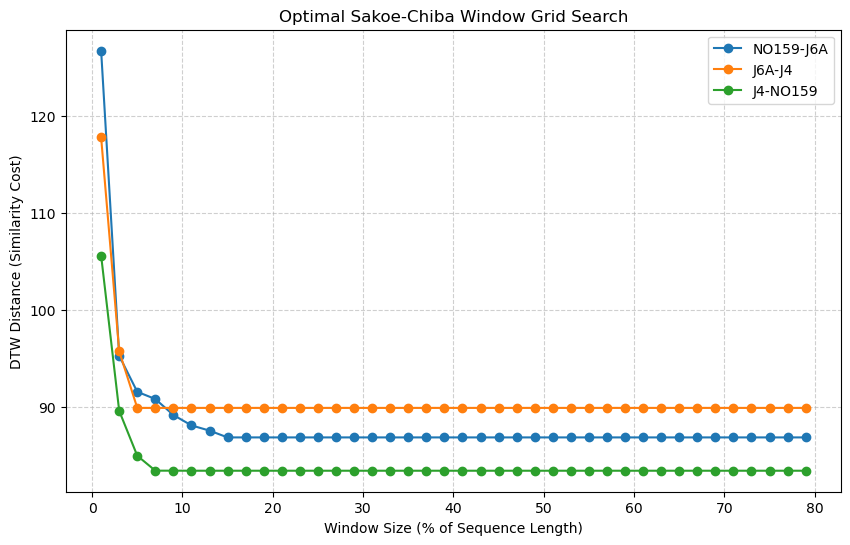

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Define DTW with Sakoe-Chiba
def dtw_sakoe_chiba(s1, s2, window):
    n, m = len(s1), len(s2)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    # Window must be at least the difference in lengths
    window = max(window, abs(n - m))
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], dtw_matrix[i, j-1], dtw_matrix[i-1, j-1])
    return dtw_matrix[n, m]

# 2. Standardize GR Logs (Assuming your df_no159, df_j6a, df_j4 are ready)
scaler = StandardScaler()
gr_no159 = scaler.fit_transform(df_no159[['GR (API)']].values).flatten()
gr_j6a = scaler.fit_transform(df_j6a[['GR (API)']].values).flatten()
gr_j4 = scaler.fit_transform(df_j4[['GR (API)']].values).flatten()

# 3. Perform Grid Search (1% to 60%)
window_percents = np.arange(1, 80, 2)
combos = [(gr_no159, gr_j6a, "NO159-J6A"), (gr_j6a, gr_j4, "J6A-J4"), (gr_j4, gr_no159, "J4-NO159")]
all_results = {}

for s1, s2, label in combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    all_results[label] = distances

# 4. Plot the Elbow Curves
plt.figure(figsize=(10, 6))
for label, distances in all_results.items():
    plt.plot(window_percents, distances, marker='o', label=label)

plt.title('Optimal Sakoe-Chiba Window Grid Search')
plt.xlabel('Window Size (% of Sequence Length)')
plt.ylabel('DTW Distance (Similarity Cost)')
plt.savefig('GR_Sakoe.png', dpi=300, bbox_inches='tight')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

In [10]:
# Create a small function to find the first percentage that hits the 'floor'
def get_best_window(percent_list, distance_list):
    # Find the minimum distance achieved
    min_dist = min(distance_list)
    # Find the index of the first time that minimum was reached
    best_index = distance_list.index(min_dist)
    # Return the corresponding percentage
    return percent_list[best_index]

# Use the variables from your previous grid search loop
best_no_j6 = get_best_window(window_percents.tolist(), all_results["NO159-J6A"])
best_j6_j4 = get_best_window(window_percents.tolist(), all_results["J6A-J4"])
best_j4_no = get_best_window(window_percents.tolist(), all_results["J4-NO159"])

print(f"Optimal Window for NO159-J6A: {best_no_j6}%")
print(f"Optimal Window for J6A-J4: {best_j6_j4}%")
print(f"Optimal Window for J4-NO159: {best_j4_no}%")

Optimal Window for NO159-J6A: 15%
Optimal Window for J6A-J4: 5%
Optimal Window for J4-NO159: 11%


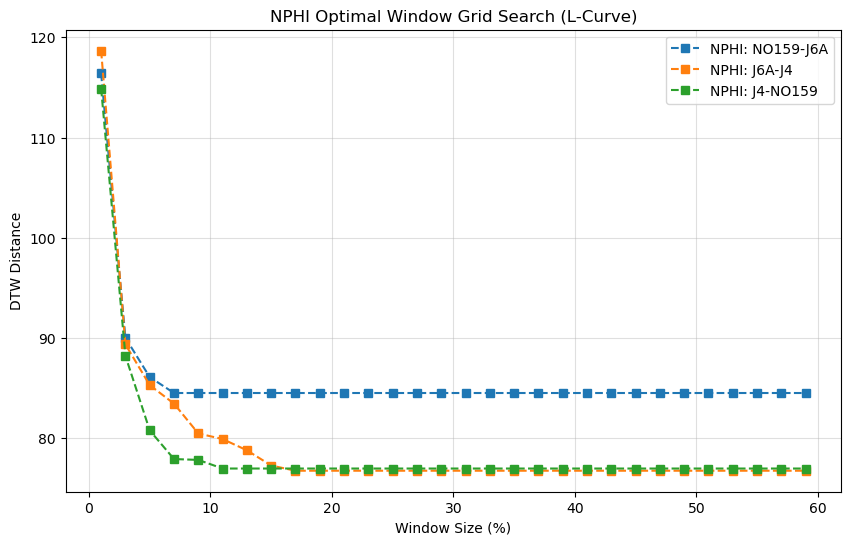

--- Optimized NPHI Windows ---
NO159-J6A: 7%
J6A-J4:    17%
J4-NO159:  11%


In [11]:
# 1. Define the range for NPHI Grid Search
window_percents = np.arange(1, 61, 2)
nphi_combos = [
    (nphi_no159, nphi_j6a, "NO159-J6A"), 
    (nphi_j6a, nphi_j4, "J6A-J4"), 
    (nphi_j4, nphi_no159, "J4-NO159")
]

nphi_grid_results = {}

# 2. Execute Grid Search for NPHI
for s1, s2, label in nphi_combos:
    distances = []
    for p in window_percents:
        w = int((p/100.0) * max(len(s1), len(s2)))
        dist = dtw_sakoe_chiba(s1, s2, w)
        distances.append(dist)
    nphi_grid_results[label] = distances

# 3. Plot NPHI L-Curves
plt.figure(figsize=(10, 6))
for label, distances in nphi_grid_results.items():
    plt.plot(window_percents, distances, marker='s', linestyle='--', label=f"NPHI: {label}")

plt.title('NPHI Optimal Window Grid Search (L-Curve)')
plt.xlabel('Window Size (%)')
plt.ylabel('DTW Distance')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

# 4. Function to identify the 'Elbow' (First point of stability)
def find_nphi_best_window(p_list, d_list):
    # Find the absolute minimum distance
    min_d = min(d_list)
    # Find the first index where the distance is within 0.5% of the minimum
    for i, d in enumerate(d_list):
        if (d - min_d) / min_d < 0.005:
            return p_list[i]
    return p_list[-1]

# 5. Output the Best Windows for NPHI
best_nphi_no_j6 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["NO159-J6A"])
best_nphi_j6_j4 = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J6A-J4"])
best_nphi_j4_no = find_nphi_best_window(window_percents.tolist(), nphi_grid_results["J4-NO159"])

print(f"--- Optimized NPHI Windows ---")
print(f"NO159-J6A: {best_nphi_no_j6}%")
print(f"J6A-J4:    {best_nphi_j6_j4}%")
print(f"J4-NO159:  {best_nphi_j4_no}%")

## l curve

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Publication-ready styling (Standardized for all plots)
# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,       # Matches Warping Path Axis Labels
    "axes.titlesize": 34,       # Matches Warping Path Title
    "legend.fontsize": 30,      # Matches Warping Path Legend
    "figure.figsize": (18, 18), # Matches Warping Path Figure Size
    "axes.linewidth": 2.0       # Matches Warping Path Spine thickness
})

def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

In [14]:
x_gr = np.arange(1, 80, 2)
y_gr = all_results["NO159-J6A"]
best_p, best_d = find_elbow(x_gr.tolist(), y_gr)


'''
plt.plot(x_gr, y_gr, color='#1f77b4', lw=2, marker='o', ms=5, label= 'DTW Cost (GR)')
plt.axvspan(best_p, max(x_gr), color='gray', alpha=0.1, label='Stability Zone')
plt.scatter(best_p, best_d, color='red', edgecolor='black', s=100, marker='*', zorder=5)


fig, ax = plt.subplots() # Use subplots for better control

ax.plot(x_gr, y_gr, color='#1f77b4', lw=5, marker='o', ms=12, label='DTW Cost (GR)')
ax.axvspan(best_p, max(x_gr), color='gray', alpha=0.15, label='Stability Zone')
ax.scatter(best_p, best_d, color='red', edgecolor='black', s=400, marker='*', zorder=10)


#plt.annotate(f'Optimum: {best_p}%', xy=(best_p, best_d), xytext=(best_p+10, best_d+1), arrowprops=dict(arrowstyle='->'))
ax.annotate(f'Optimum Window: {best_p}%', xy=(best_p, best_d), xytext=(best_p+10, best_d + 5),
             fontsize=30, fontweight='bold', # Set font specifically
             arrowprops=dict(arrowstyle='->', connectionstyle="arc3,rad=.2", lw=2),
             bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.5))


# 3. MATCHING TICK LABELS
ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


ax.set_title("Optimization: J6A vs NO159-2 (Gamma Ray)", pad=30)
ax.set_xlabel("Sakoe-Chiba Window Size (% of Sequence Length)", labelpad=15)
ax.set_ylabel("DTW Distance (Similarity Cost)", labelpad= 15)
ax.grid(True, linestyle='--', alpha=0.6)

ax.legend(loc='upper right', frameon=True, shadow=True, framealpha=0.9)

plt.tight_layout()

plt.savefig("L_curve/NO159(2)_J6A_GR.jpg", dpi=300, bbox_inches='tight')
plt.show()


'''



'\nplt.plot(x_gr, y_gr, color=\'#1f77b4\', lw=2, marker=\'o\', ms=5, label= \'DTW Cost (GR)\')\nplt.axvspan(best_p, max(x_gr), color=\'gray\', alpha=0.1, label=\'Stability Zone\')\nplt.scatter(best_p, best_d, color=\'red\', edgecolor=\'black\', s=100, marker=\'*\', zorder=5)\n\n\nfig, ax = plt.subplots() # Use subplots for better control\n\nax.plot(x_gr, y_gr, color=\'#1f77b4\', lw=5, marker=\'o\', ms=12, label=\'DTW Cost (GR)\')\nax.axvspan(best_p, max(x_gr), color=\'gray\', alpha=0.15, label=\'Stability Zone\')\nax.scatter(best_p, best_d, color=\'red\', edgecolor=\'black\', s=400, marker=\'*\', zorder=10)\n\n\n#plt.annotate(f\'Optimum: {best_p}%\', xy=(best_p, best_d), xytext=(best_p+10, best_d+1), arrowprops=dict(arrowstyle=\'->\'))\nax.annotate(f\'Optimum Window: {best_p}%\', xy=(best_p, best_d), xytext=(best_p+10, best_d + 5),\n             fontsize=30, fontweight=\'bold\', # Set font specifically\n             arrowprops=dict(arrowstyle=\'->\', connectionstyle="arc3,rad=.2", lw=2

In [15]:

import matplotlib.pyplot as plt
import numpy as np

# 1. MATCHING GLOBAL STYLE (Synchronized with Warping Path & GR)
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.labelsize": 30,       # Matches Warping Path Axis Labels
    "axes.titlesize": 34,       # Matches Warping Path Title
    "legend.fontsize": 30,      # Matches Warping Path Legend
    "figure.figsize": (18, 18), # Matches Warping Path 1:1 Aspect Ratio
    "axes.linewidth": 2.0       # Matches Warping Path Spine thickness
})



x_nphi = np.arange(1, 61, 2)
y_nphi = nphi_grid_results["NO159-J6A"]
best_p_nphi, best_d_nphi = find_elbow(x_nphi.tolist(), y_nphi)
'''
fig, ax = plt.subplots()
ax.plot(x_nphi, y_nphi, color='#2ca02c', lw=5, marker='s', ms=12, label='DTW Cost (NPHI)')
ax.axvspan(best_p_nphi, max(x_nphi), color='gray', alpha=0.15, label='Stability Zone')

ax.scatter(best_p_nphi, best_d_nphi, color='red', edgecolor='black', s=400, marker='*', zorder=10)

# --- SAFE OFFSET BASED ON DATA RANGE ---
y_offset = (max(y_nphi) - min(y_nphi)) * 0.2
x_offset = 5

ax.annotate(f'Optimum Window: {int(best_p_nphi)}%',
            xy=(best_p_nphi, best_d_nphi),
            xytext=(best_p_nphi + x_offset, best_d_nphi + y_offset),
            fontsize=30, fontweight='bold',
            arrowprops=dict(arrowstyle='->',
                            connectionstyle="arc3,rad=.2",
                            lw=2),
            bbox=dict(boxstyle="round,pad=0.4",
                      fc="white", ec="black", lw=1.5))
# 4. MATCHING TICK LABELS (16pt Bold)
ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


ax.set_title("Optimization: J6A vs NO159-2 (NPHI)",pad=30)
ax.set_xlabel("Window Size (%)", labelpad=15)
ax.set_ylabel("DTW Distance", labelpad=15)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True, shadow=True, framealpha=0.9)

plt.savefig("L_curve/NO159(2)_J6A_NPHI.jpg", dpi=300, bbox_inches='tight')

#plt.show()





# 4. MATCHING TICK LABELS (16pt Bold)
ax.tick_params(axis='both', which='major', labelsize=30, width=2, length=8)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


ax.set_title("Optimization: J6A vs NO159-2 (NPHI)",pad=30)
ax.set_xlabel("Window Size (%)", labelpad=15)
ax.set_ylabel("DTW Distance", labelpad=15)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', frameon=True, shadow=True, framealpha=0.9)

plt.savefig("L_curve/NO159(2)_J6A_NPHI.jpg", dpi=300, bbox_inches='tight')

plt.show()



'''

'\nfig, ax = plt.subplots()\nax.plot(x_nphi, y_nphi, color=\'#2ca02c\', lw=5, marker=\'s\', ms=12, label=\'DTW Cost (NPHI)\')\nax.axvspan(best_p_nphi, max(x_nphi), color=\'gray\', alpha=0.15, label=\'Stability Zone\')\n\nax.scatter(best_p_nphi, best_d_nphi, color=\'red\', edgecolor=\'black\', s=400, marker=\'*\', zorder=10)\n\n# --- SAFE OFFSET BASED ON DATA RANGE ---\ny_offset = (max(y_nphi) - min(y_nphi)) * 0.2\nx_offset = 5\n\nax.annotate(f\'Optimum Window: {int(best_p_nphi)}%\',\n            xy=(best_p_nphi, best_d_nphi),\n            xytext=(best_p_nphi + x_offset, best_d_nphi + y_offset),\n            fontsize=30, fontweight=\'bold\',\n            arrowprops=dict(arrowstyle=\'->\',\n                            connectionstyle="arc3,rad=.2",\n                            lw=2),\n            bbox=dict(boxstyle="round,pad=0.4",\n                      fc="white", ec="black", lw=1.5))\n# 4. MATCHING TICK LABELS (16pt Bold)\nax.tick_params(axis=\'both\', which=\'major\', labelsize=30, w

## warping path

## Correlation images

In [18]:


import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Dummy zone definitions mapped to fit your 5000-5130 ft verification datasets
zones_no159_2 = {
    'Asl Marl': (5000, 5040, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5040, 5090, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5090, 5130, '#d9ead3')   # Light Green
}

zones_j6a= {
    'Asl Marl': (5000, 5045, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5045, 5095, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5095, 5130, '#d9ead3')   # Light Green
}
# We'll assume J6A follows a similar stratigraphic sequence 
# based on your window search results.

In [19]:
def plot_correlation(df1, df2, label1, label2, window_p):
    fig, axes = plt.subplots(1, 2, figsize=(10, 12), sharey=False)
    
    # Calculate warping path using your dtw_sakoe_chiba logic
    # (Extract the path indices i, j from your DTW matrix)
    # path = get_dtw_path(s1, s2, window_p) 

    for ax, df, zones, name in zip(axes, [df1, df2], [zones_no159, zones_j4], [label1, label2]):
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]
        
        # Plot GR Log
        ax.plot(gr, depth, color='black', lw=0.7)
        ax.set_title(name)
        ax.invert_yaxis()
        
        # Color the Zones
        for zone, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, color=color, alpha=0.5, label=zone)
            # Add text label for lithology
            ax.text(ax.get_xlim()[1], (top+bottom)/2, zone, verticalalignment='center')

    # Draw Correlation Lines (Connect points using the DTW path)
    # This visually shows how the "Thick Beds" match despite depth shifts
    plt.tight_layout()
    plt.show()

# Example call using your optimized 37% window for NO159-J6A
# plot_correlation(df_no159, df_j6a, "NO159-2", "J6A", 0.37)

In [20]:
def dtw_with_path(s1, s2, window_p):
    n, m = len(s1), len(s2)
    window = max(int(window_p * max(n, m)), abs(n - m))
    
    # Initialize cost matrix
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Fill matrix
    for i in range(1, n + 1):
        for j in range(max(1, i - window), min(m + 1, i + window + 1)):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # Backtrack to find the path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        # Find the minimum neighbor to step back to
        prev_steps = [dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]]
        best_step = np.argmin(prev_steps)
        if best_step == 0: i, j = i-1, j-1
        elif best_step == 1: i -= 1
        else: j -= 1
    
    return path[::-1] # Return path from beginning to end

In [21]:
plt.rcParams.update({
    "font.family": "serif",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold"
})

## final plotting 

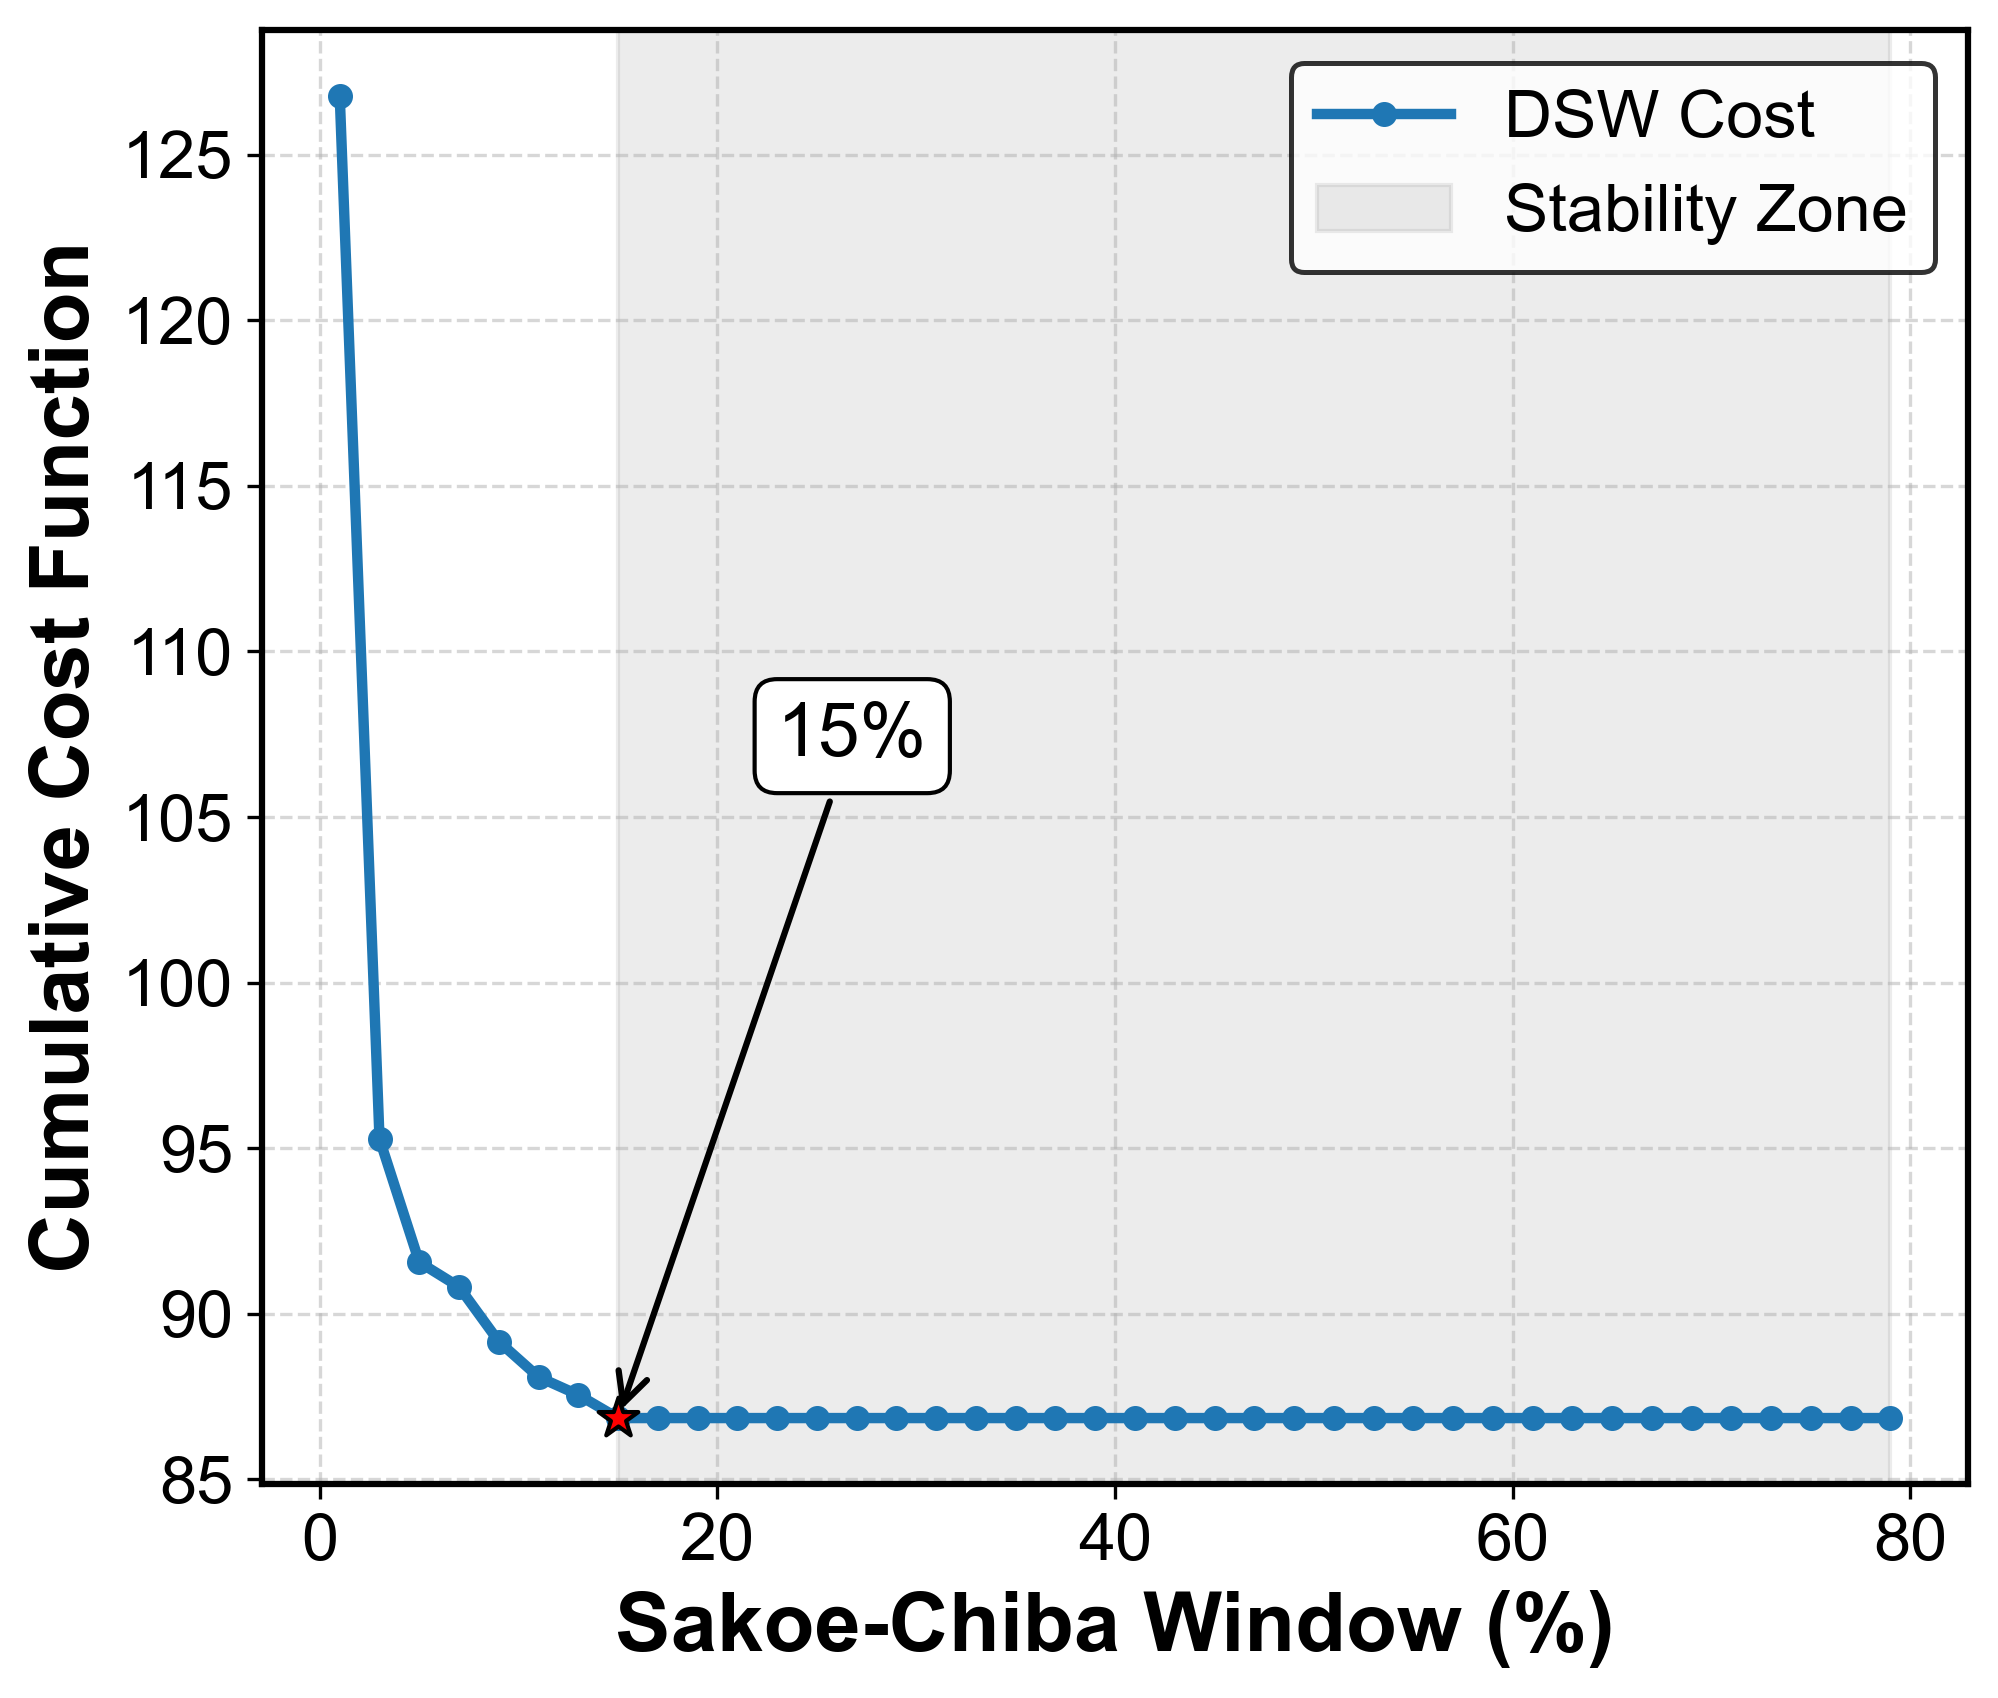

In [23]:

import numpy as np
import matplotlib.pyplot as plt

# 1. APPLY CLEAN GLOBAL STYLE (Matching Plot 1)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

# Data setup
x_gr = np.arange(1, 80, 2)
y_gr = all_results["NO159-J6A"]
best_p, best_d = find_elbow(x_gr.tolist(), y_gr)

# 2. CREATE PLOT (Compact 7x6 size)
fig, ax = plt.subplots(figsize=(7,6))

# Plot line and marker style
ax.plot(x_gr, y_gr, color='#1f77b4', lw=2.5, marker='o', ms=5, label='DSW Cost')

# Stability zone (Matches first plot alpha)
ax.axvspan(best_p, max(x_gr), color='gray', alpha=0.15, label='Stability Zone')

# Optimal point (Star marker)
ax.scatter(best_p, best_d, color='red', edgecolor='black', s=100, marker='*', zorder=10)

# 3. CLEAN ANNOTATION (Matches Plot 1 format)
ax.annotate(f'{best_p}%',
            xy=(best_p, best_d),
            xytext=(best_p + 8, best_d + 20), # Adjusted for J6A scale
            arrowprops=dict(arrowstyle='->', lw=1.5),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

# 4. BORDER & GRID STYLING
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

# Labels (Simplified to match Plot 1)
ax.set_xlabel("Sakoe-Chiba Window (%)")
ax.set_ylabel("Cumulative Cost Function")

# Legend (Clean + Visible)
leg = ax.legend(loc='upper right', frameon=True)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.2)

ax.grid(True, linestyle='--', alpha=0.5)

# 5. FINAL EXPORT
plt.tight_layout()
plt.savefig("L_curve/NO159(2)_J6A_GR_Clean.jpg", bbox_inches='tight', pad_inches=0.02)
plt.show()

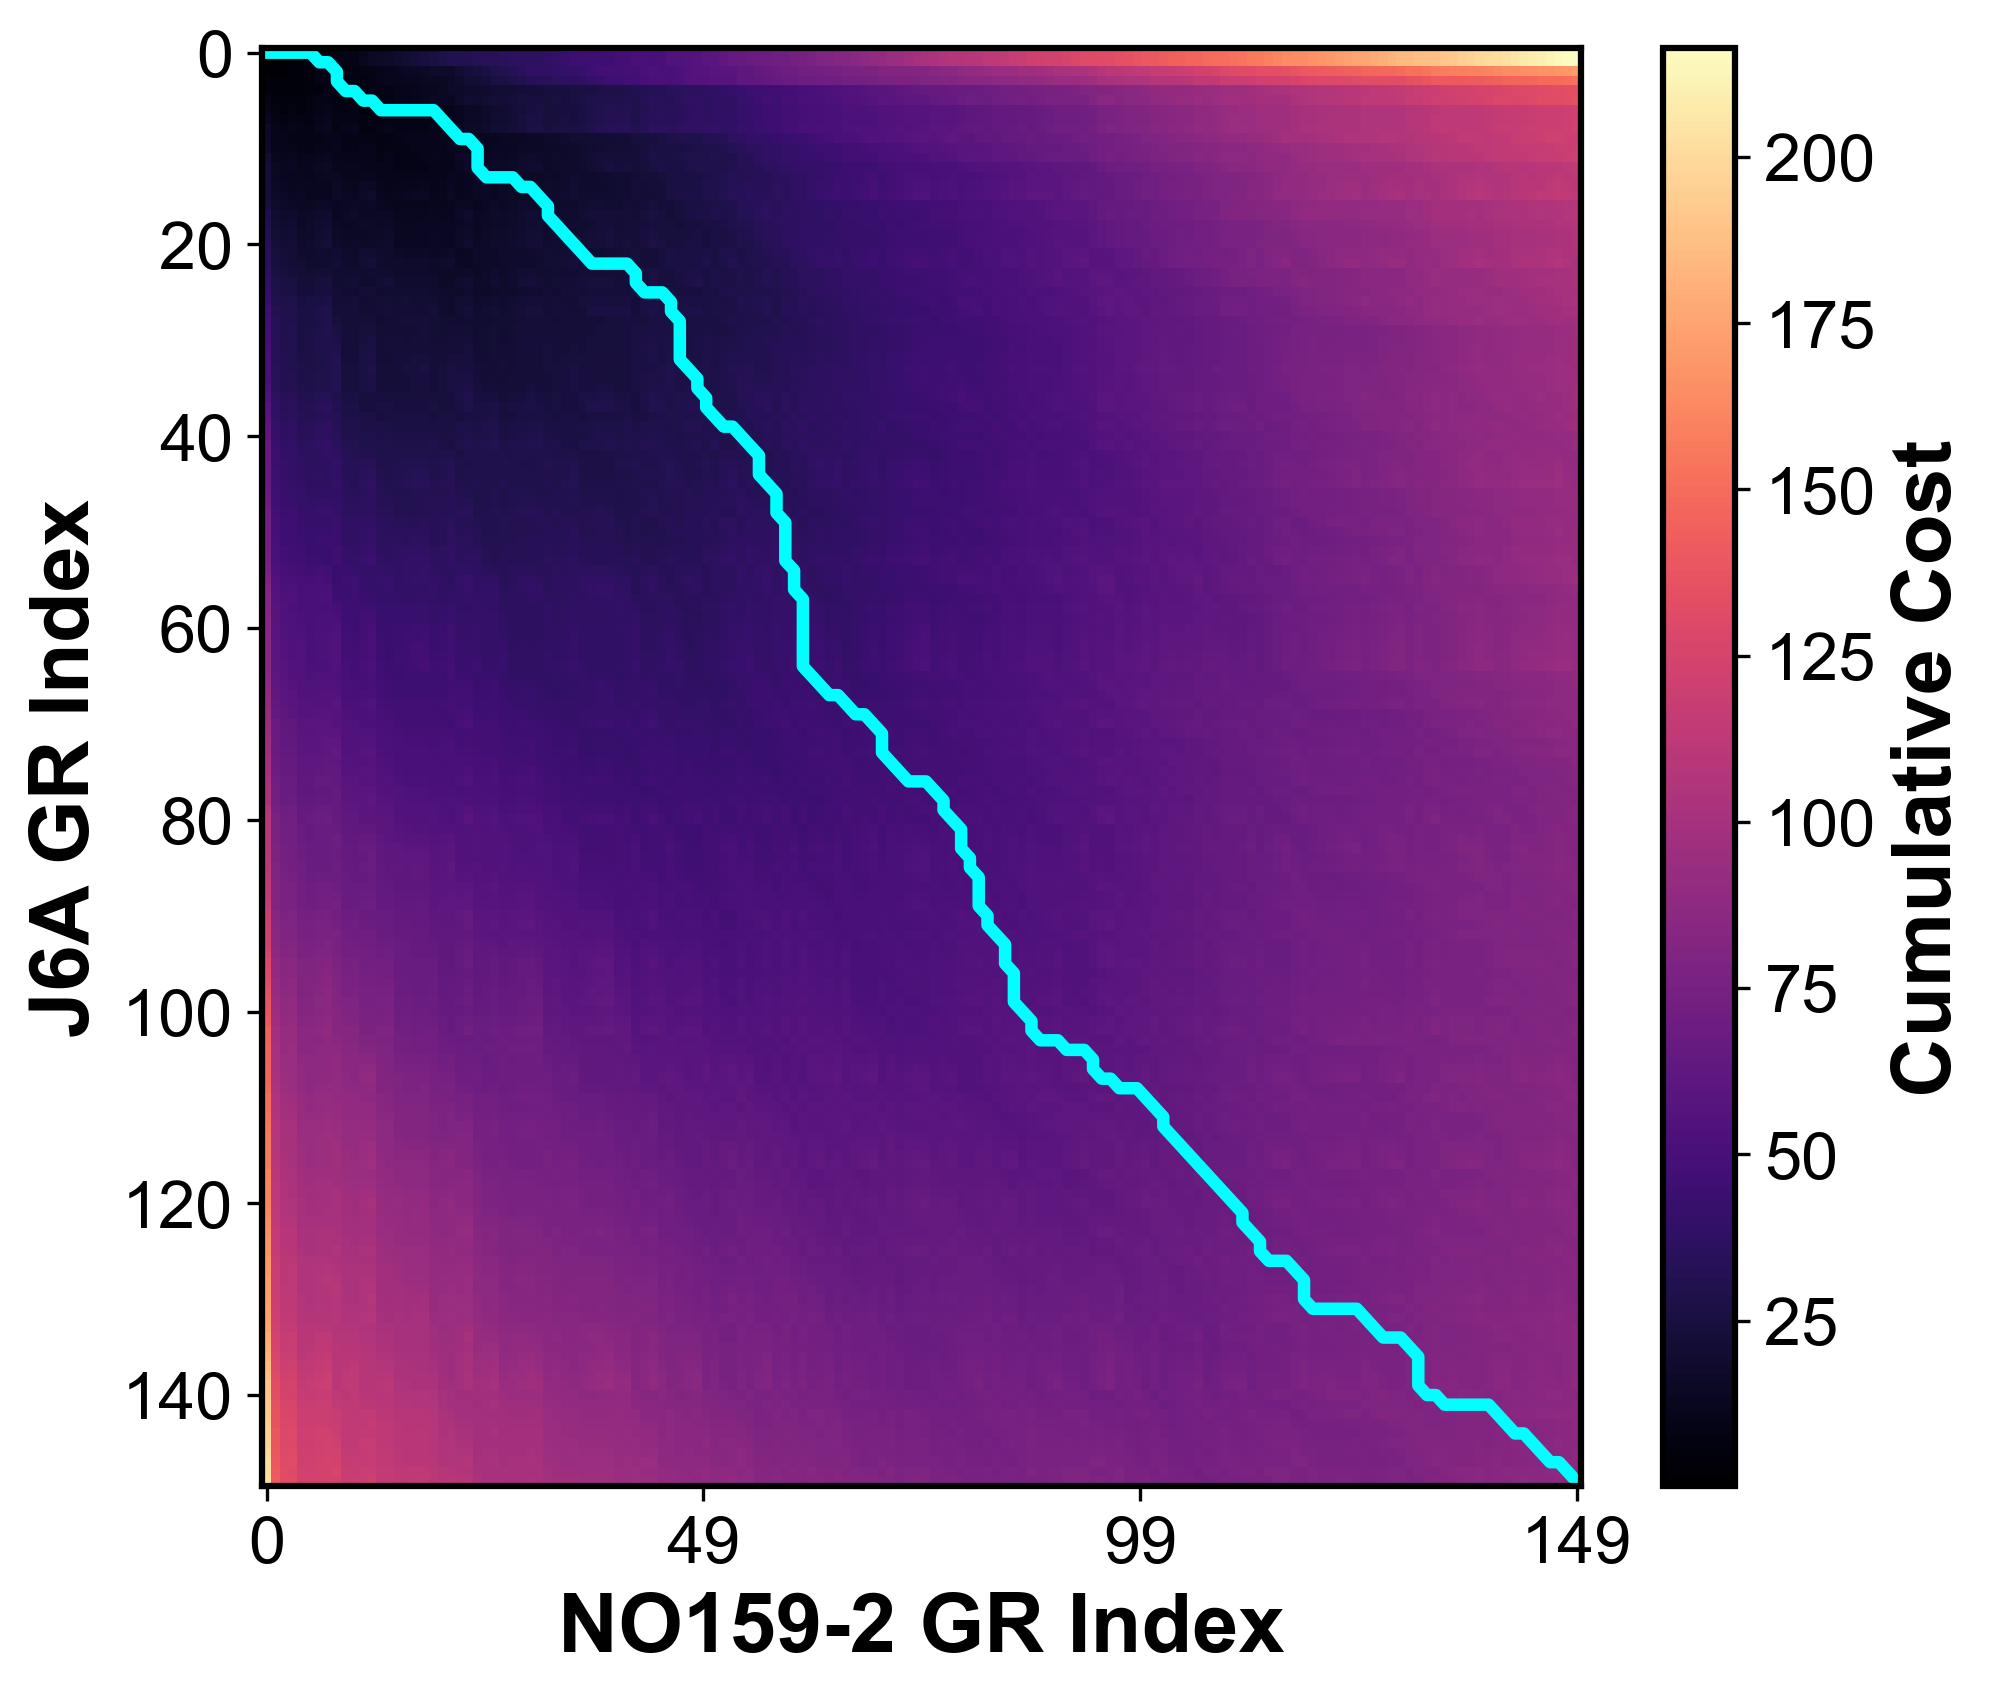

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# 1. APPLY CLEAN GLOBAL STYLE
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_warping_full_matrix(df1, df2, label1, label2):
    # Standardize data (Column index 1 for Gamma Ray)
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    
    # 2. FULL DTW CALCULATION (Removed Windowing)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    # Fill the entire matrix instead of just a diagonal band
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # 3. Backtracking
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        move = np.argmin([dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]])
        if move == 0: i, j = i-1, j-1
        elif move == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 4. VISUALS (Full Matrix Style)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Slice matrix to ignore the padding row/column used for calculation
    matrix_to_show = dtw_matrix[1:, 1:]
    
    # aspect='auto' ensures it fills the 7x6 frame even if sequence lengths differ
    img = ax.imshow(matrix_to_show.T, origin='upper', cmap='magma', aspect='auto')

    # Path style matching Plot 1
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)

    # Simplified Labels matching your first screenshot
    ax.set_xlabel(f"{label1} GR Index")
    ax.set_ylabel(f"{label2} GR Index")

    # Consistent X-tick spacing (4 ticks)
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])

    # Colorbar matching Plot 1
    cbar = plt.colorbar(img)
    cbar.set_label("Cumulative Cost")

    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    plt.tight_layout()

    # Save logic
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_GR_FullWarping.jpg"
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# --- EXECUTE ---
plot_warping_full_matrix(df_no159, df_j6a, "NO159-2", "J6A")

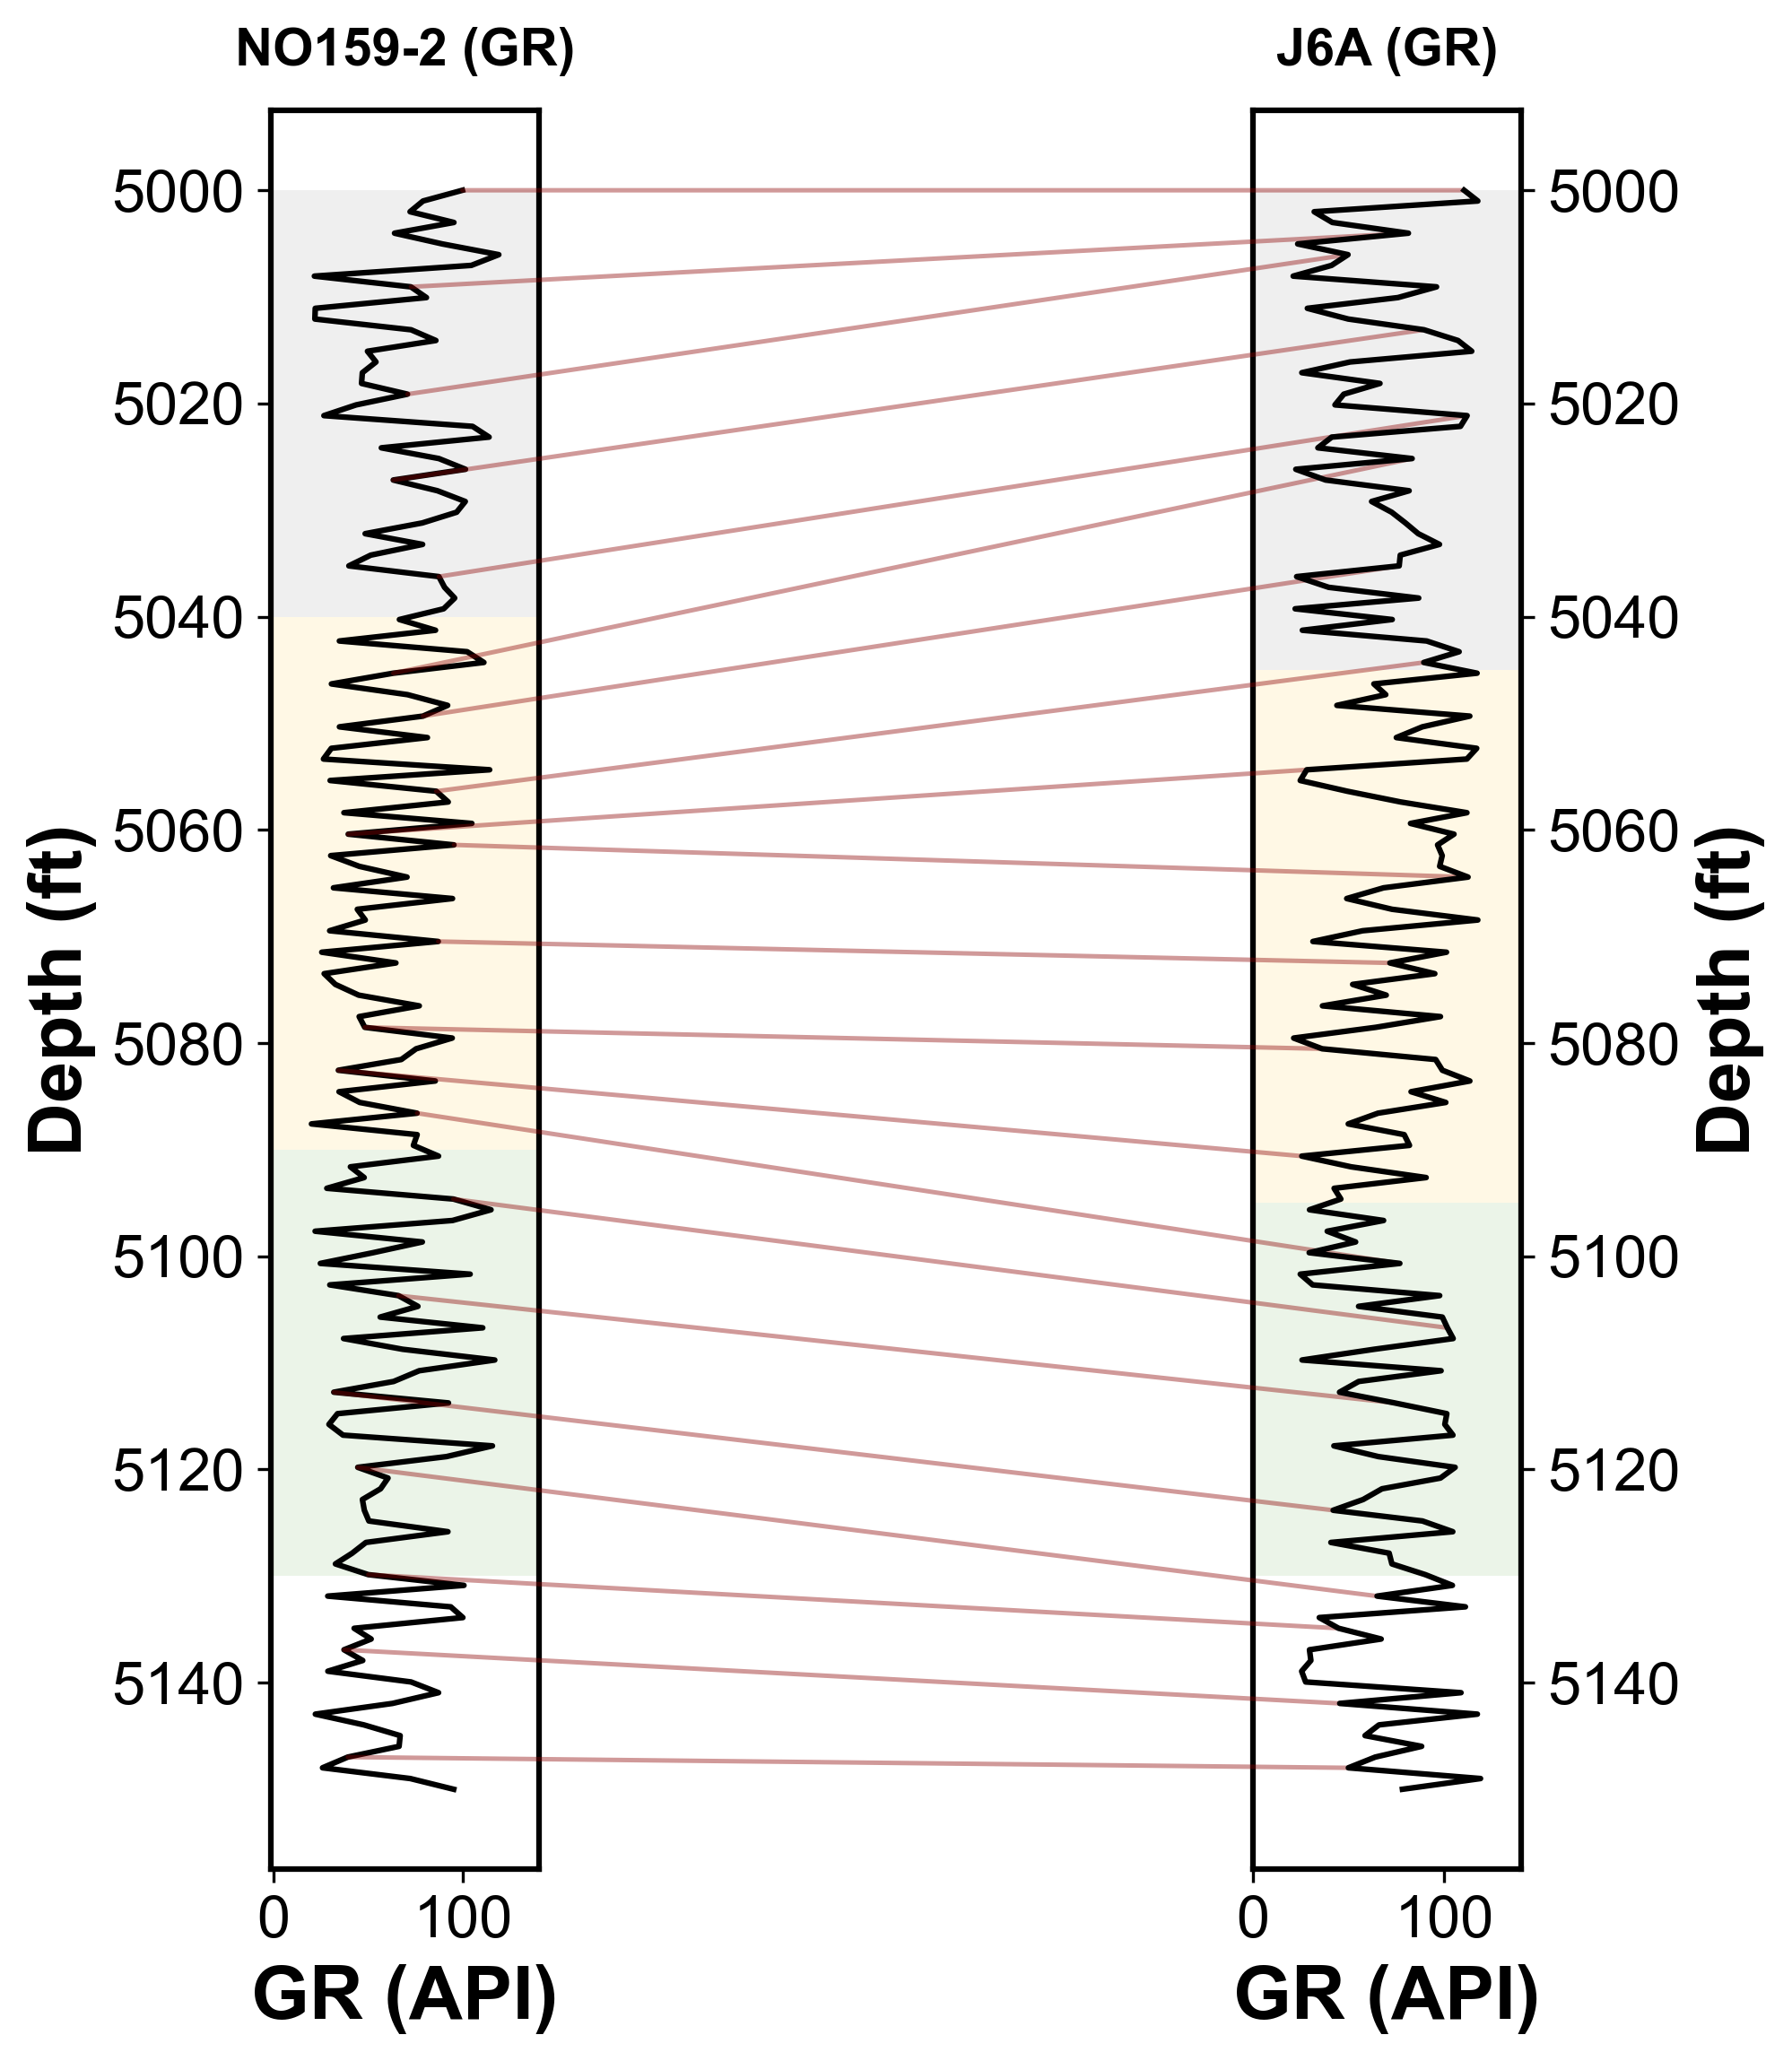

In [25]:
import os
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler

# Publication-ready styling (Standardized)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 1.5,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

# --- FIX 1: DUMMY ZONE DEFINITIONS (Scaled to fit the 5000-5130 ft test data range) ---
zones_no159_2_dummy = {
    'Asl Marl': (5000, 5040, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5040, 5090, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5090, 5130, '#d9ead3')   # Light Green
}

zones_j6a_dummy = {
    'Asl Marl': (5000, 5045, '#e0e0e0'),   # Light Gray
    'Asl Sand': (5045, 5095, '#fff2cc'),   # Pale Yellow
    'Hawara Fm': (5095, 5130, '#d9ead3')   # Light Green
}

def plot_gr_correlation_clean(df1, df2, zones1, zones2, label1, label2, window_p):
    # 1. Standardize GR logs (Column Index 1)
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 1].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 1].values.reshape(-1,1)).flatten()

    # Calculate path using your existing dtw_with_path function
    path = dtw_with_path(s1, s2, window_p)

    # 2. Setup Figure (7,8 aspect ratio for correlation)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        gr = df.iloc[:, 1]

        # Plot log with publication thickness
        ax.plot(gr, depth, color='black', lw=1.5, zorder=5)

        ax.invert_yaxis()
        ax.set_title(f"{name} (GR)", fontweight='bold', pad=12, fontsize=14) # Track well names
        ax.set_xlabel("GR (API)")
        ax.set_ylabel("Depth (ft)")

        # Secondary labels for the right-hand well
        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()

        # 3. Stratigraphic Zones (FIXED: Using facecolor to clear matplotlib color warning)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # Spacing fix to prevent curve touching spines
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Border styling
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

    # 4. Correlation Lines 
    # --- FIX 2: Reduced step size from 120 to 10 so lines aren't skipped on test data ---
    line_density_step = 10 
    for k in range(0, len(path), line_density_step):
        i1, i2 = path[k]

        y1, x1 = df1.iloc[i1, 0], df1.iloc[i1, 1]
        y2, x2 = df2.iloc[i2, 0], df2.iloc[i2, 1]

        con = ConnectionPatch(
            xyA=(x1, y1), xyB=(x2, y2),
            coordsA="data", coordsB="data",
            axesA=axes[0], axesB=axes[1],
            color="darkred", lw=1.2, alpha=0.4, zorder=4
        )
        axes[1].add_artist(con)

    plt.tight_layout()
    
    # Save to your L_curve directory
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_name = f"L_curve/{label1}_{label2}_GR_Correlation.jpg"
    plt.savefig(save_name, bbox_inches='tight', dpi=300)
    plt.show()

# --- EXECUTE ---
# --- FIX 3: Passed the dummy zone definitions to align with your validation file limits ---
plot_gr_correlation_clean(df_no159, df_j6a, zones_no159_2_dummy, zones_j6a_dummy, 
                          "NO159-2", "J6A", 0.15)

## for NPHI

Matched NPHI L-Curve saved to: L_curve/NO159(2)_J6A_NPHI_Matched.jpg


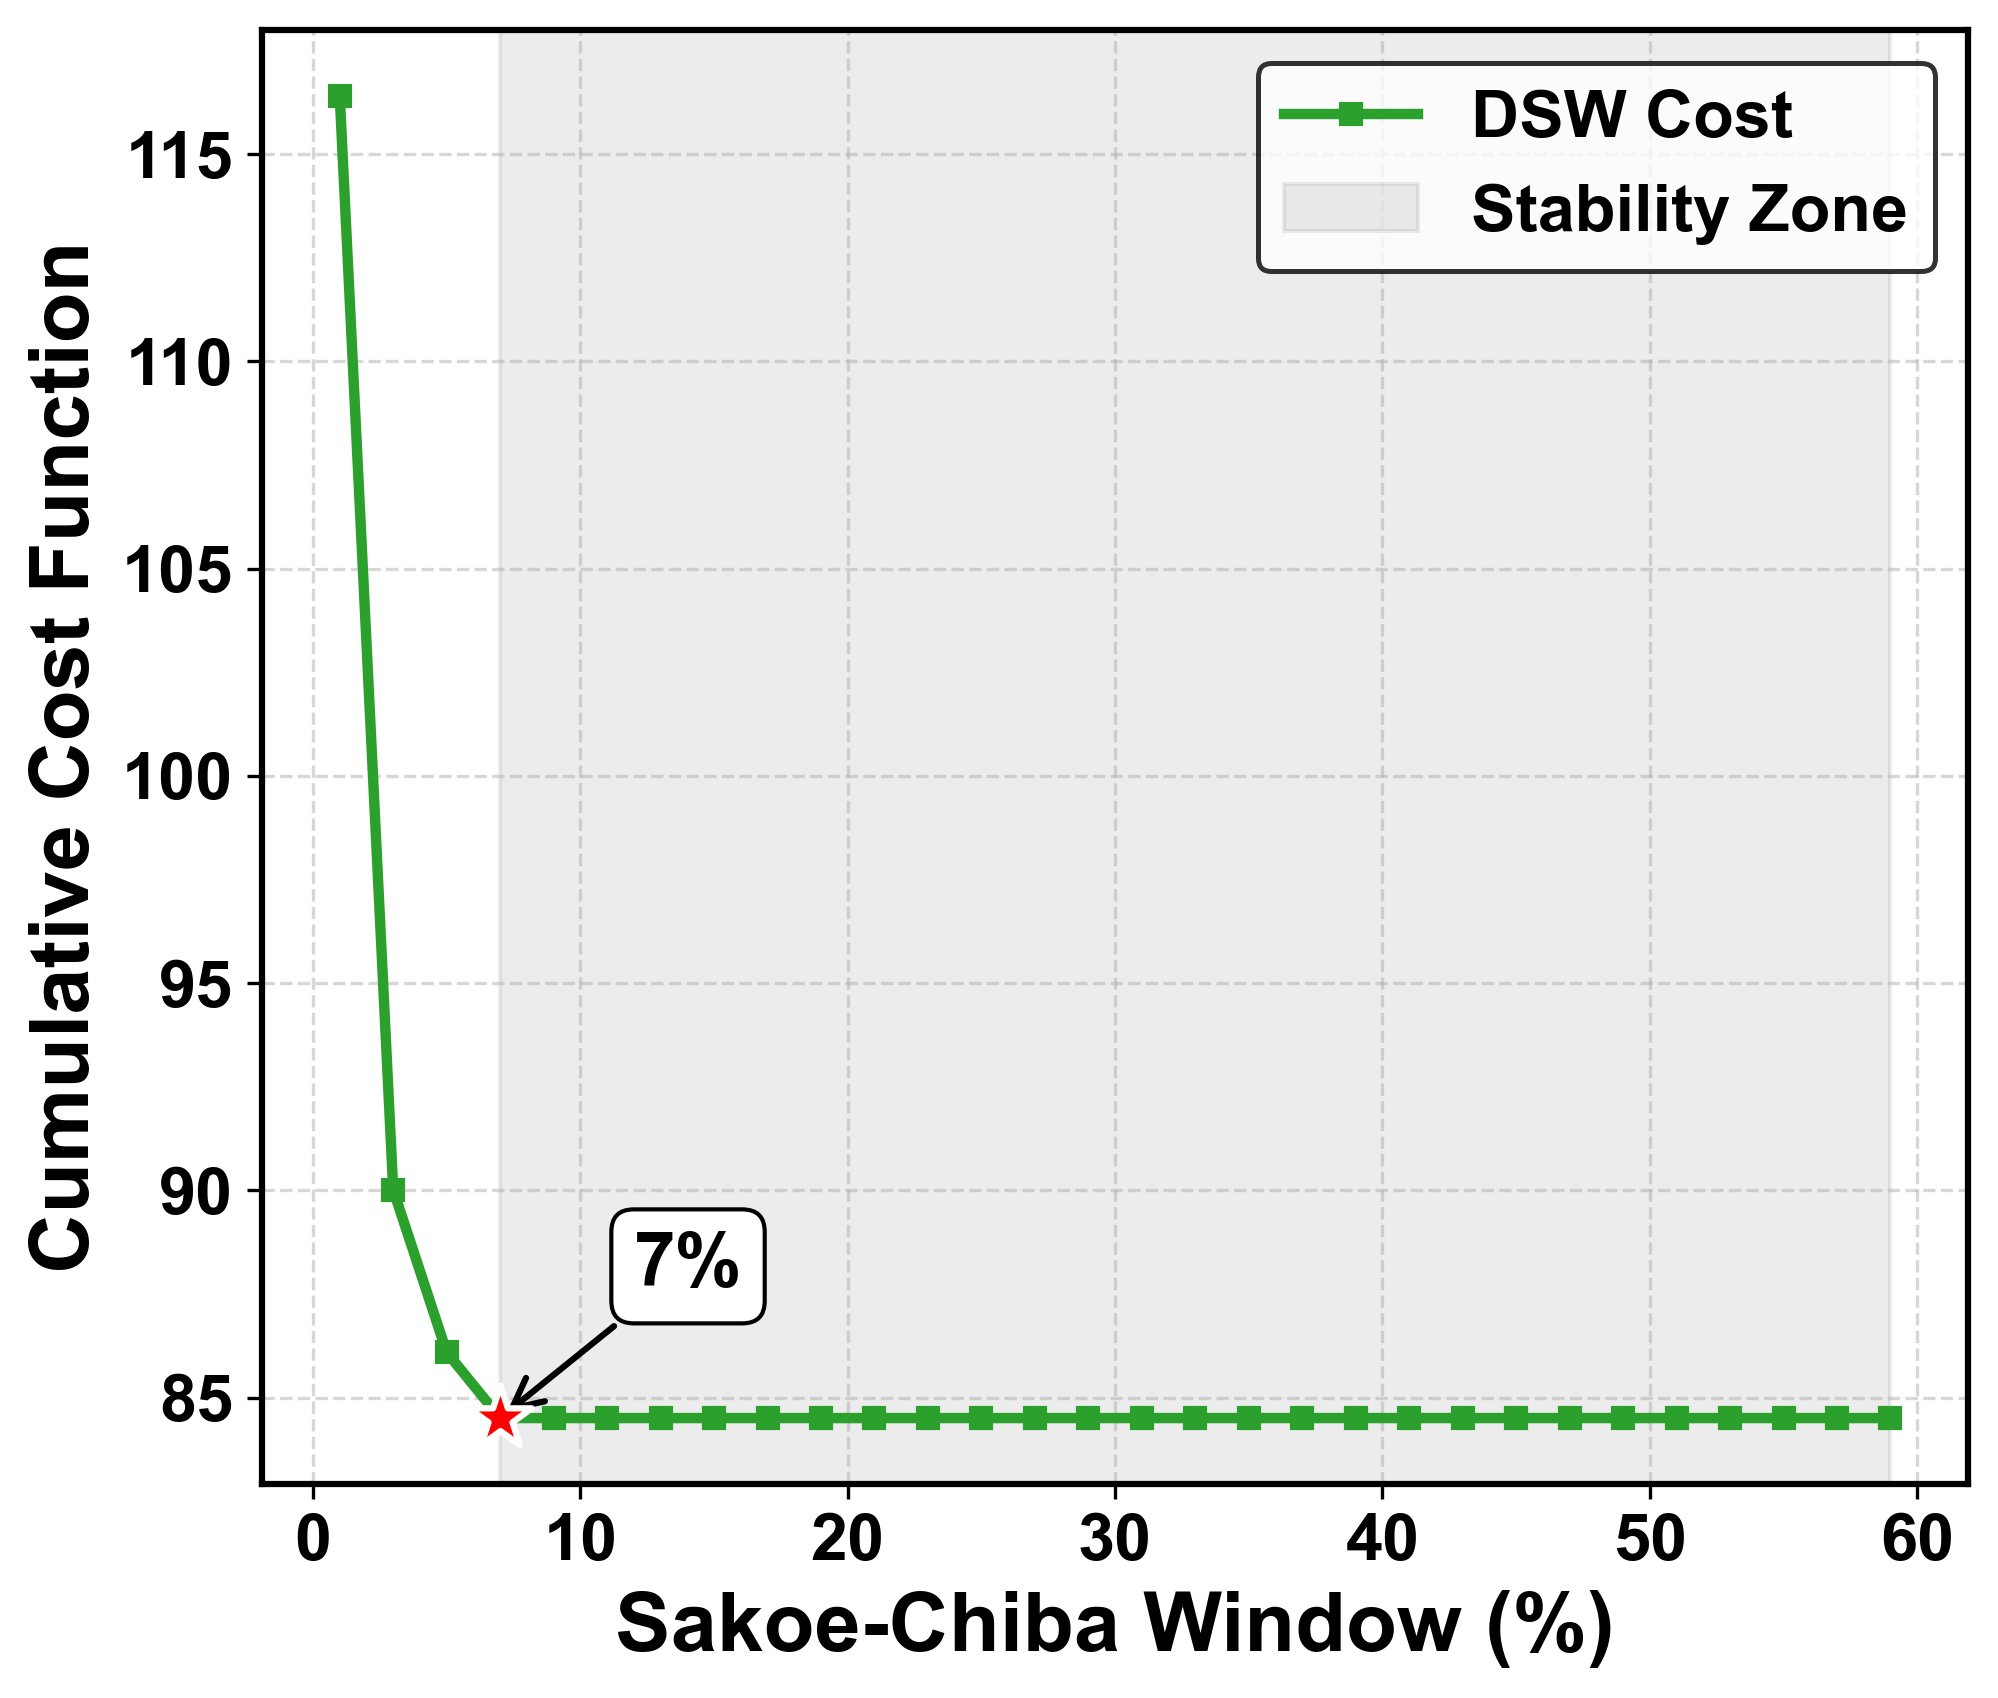

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. MATCHING GLOBAL STYLE (Arial + Compact Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def find_elbow(p_list, d_list):
    min_d = min(d_list)
    for i, d in enumerate(d_list):
        if (d - min_d) / (min_d if min_d != 0 else 1) < 0.005:
            return p_list[i], d_list[i]
    return p_list[-1], d_list[-1]

# Data Setup
x_nphi = np.arange(1, 61, 2)
y_nphi = nphi_grid_results["NO159-J6A"]
best_p_nphi, best_d_nphi = find_elbow(x_nphi.tolist(), y_nphi)

# 2. MATCHING FIGURE SIZE (7x6)
fig, ax = plt.subplots(figsize=(7, 6))

# Plot Data (Green #2ca02c with square markers 's')
ax.plot(x_nphi, y_nphi, color='#2ca02c', lw=2.5, marker='s', ms=5, label='DSW Cost')

# Stability Zone
ax.axvspan(best_p_nphi, max(x_nphi), color='gray', alpha=0.15, label='Stability Zone')

# Optimal Point (Red Star with white edge)
ax.scatter(best_p_nphi, best_d_nphi, color='red', edgecolor='white', 
           linewidth=1.5, s=250, marker='*', zorder=20)

# 3. MATCHING ANNOTATION (Short arrow logic)
y_range = max(y_nphi) - min(y_nphi)
y_text_offset = best_d_nphi + (y_range * 0.10) # 10% offset for short arrow

ax.annotate(f'{int(best_p_nphi)}%',
            xy=(best_p_nphi, best_d_nphi),
            xytext=(best_p_nphi + 5, y_text_offset),
            fontsize=18,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.5),
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

# 4. BORDERS & TICK FORMATTING
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_edgecolor('black')

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

# Labels
ax.set_xlabel("Sakoe-Chiba Window (%)")
ax.set_ylabel("Cumulative Cost Function")

# 5. CLEAN LEGEND
leg = ax.legend(loc='upper right', frameon=True)
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.2)
for text in leg.get_texts():
    text.set_fontweight('bold')

ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save
if not os.path.exists('L_curve'): os.makedirs('L_curve')
save_path = "L_curve/NO159(2)_J6A_NPHI_Matched.jpg"
plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
print(f"Matched NPHI L-Curve saved to: {save_path}")

plt.show()

Full NPHI Matrix saved to: L_curve/NO159-2_J6A_NPHI_FullMatrix.jpg


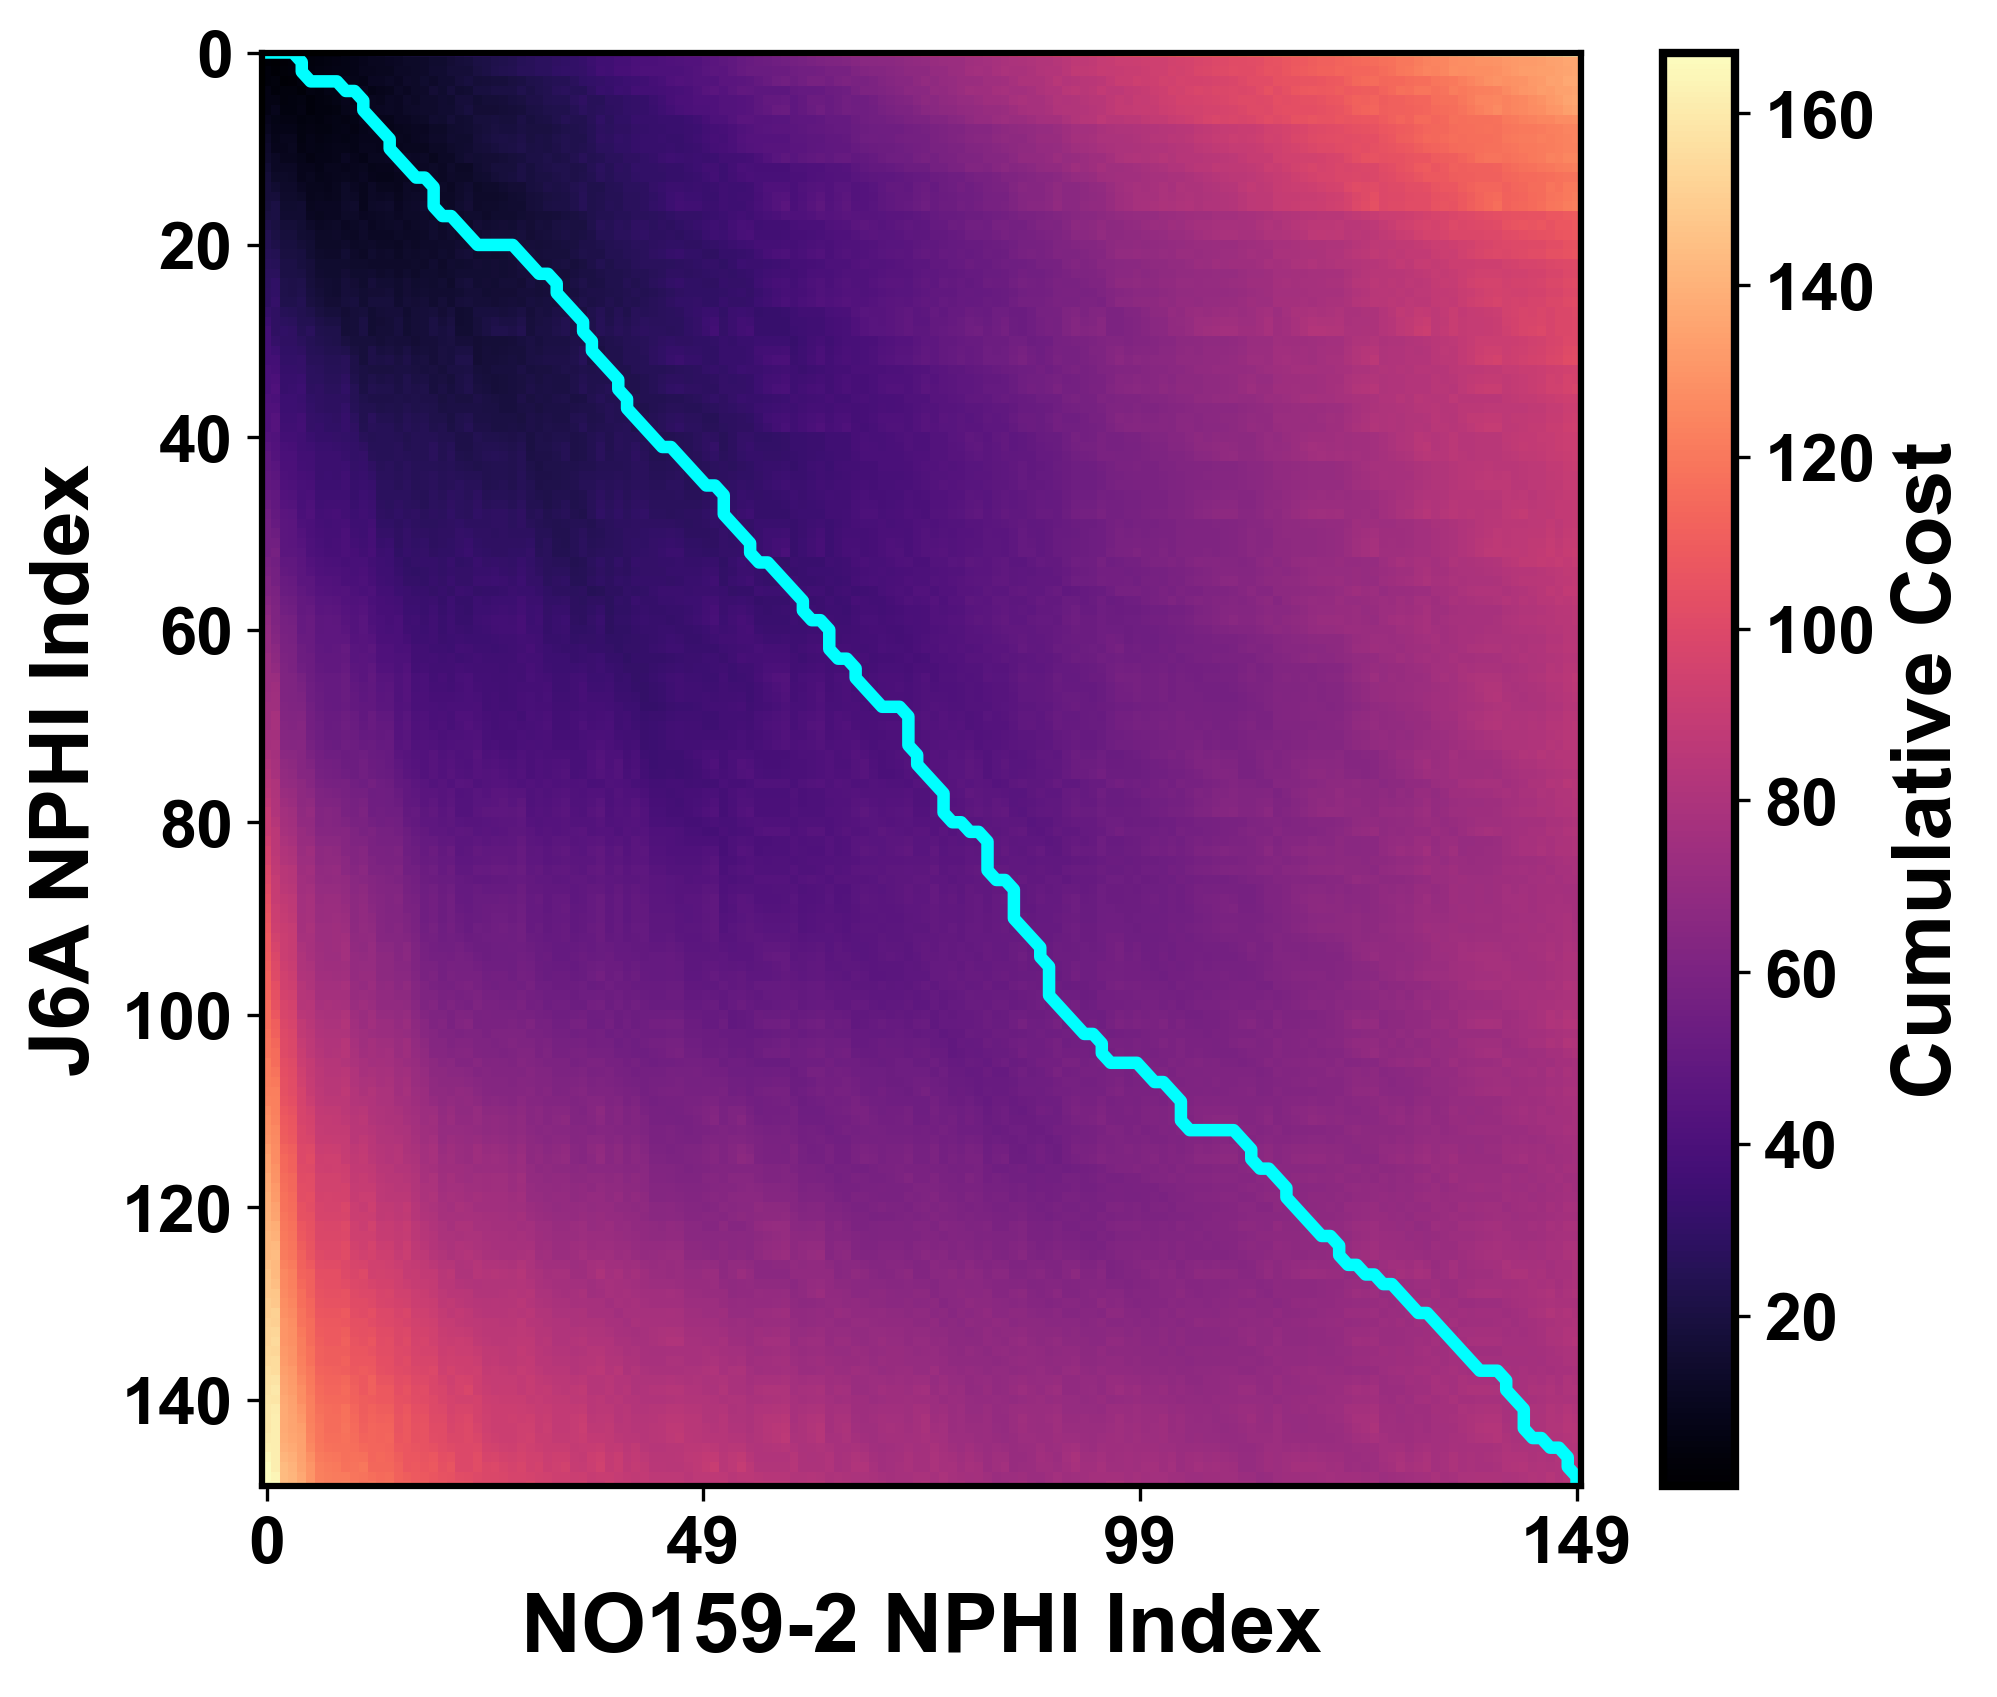

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import os

# 1. MATCHING GLOBAL STYLE
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.labelweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_full_matrix_matched(df1, df2, label1, label2):
    # 2. Standardize NPHI
    scaler = StandardScaler()
    s1 = scaler.fit_transform(df1.iloc[:, 2].values.reshape(-1,1)).flatten()
    s2 = scaler.fit_transform(df2.iloc[:, 2].values.reshape(-1,1)).flatten()
    
    n, m = len(s1), len(s2)
    
    # 3. COMPUTE FULL MATRIX (No Window Constraints)
    dtw_matrix = np.full((n + 1, m + 1), np.inf)
    dtw_matrix[0, 0] = 0
    
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s1[i-1] - s2[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j], 
                                          dtw_matrix[i, j-1], 
                                          dtw_matrix[i-1, j-1])
    
    # 4. Backtracking for Optimal Path
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i - 1, j - 1))
        move = np.argmin([dtw_matrix[i-1, j-1], dtw_matrix[i-1, j], dtw_matrix[i, j-1]])
        if move == 0: i, j = i-1, j-1
        elif move == 1: i -= 1
        else: j -= 1
    path = np.array(path[::-1])

    # 5. VISUALIZATION (7x6 Size)
    fig, ax = plt.subplots(figsize=(7, 6))

    # Plot the full matrix (slicing out the padding row/column)
    full_matrix = dtw_matrix[1:, 1:]
    img = ax.imshow(full_matrix.T, origin='upper', cmap='magma', aspect='auto')

    # Optimal Path (Cyan)
    ax.plot(path[:, 0], path[:, 1], color='cyan', linewidth=3)

    # 6. LABELS & AXIS FORMATTING
    ax.set_xlabel(f"{label1} NPHI Index")
    ax.set_ylabel(f"{label2} NPHI Index")
    
    # Clean up axes: No negative space, bold ticks
    ax.set_ylim(m - 1, 0) 
    
    xticks = np.linspace(0, n-1, 4)
    ax.set_xticks(xticks)
    ax.set_xticklabels([int(x) for x in xticks])
    
    for t in ax.get_xticklabels() + ax.get_yticklabels():
        t.set_fontweight('bold')

    # Spines
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

    # Colorbar
    cbar = plt.colorbar(img)
    cbar.set_label('Cumulative Cost', fontweight='bold')
    for t in cbar.ax.get_yticklabels():
        t.set_fontweight('bold')

    plt.tight_layout()

    # SAVE
    if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_path = f"L_curve/{label1}_{label2}_NPHI_FullMatrix.jpg"
    plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    
    print(f"Full NPHI Matrix saved to: {save_path}")
    plt.show()

# --- EXECUTE ---
plot_nphi_full_matrix_matched(df_no159, df_j6a, "NO159-2", "J6A")

Matched Correlation Plot saved to: L_curve/NO159-2_J6A_NPHI_Correlation.jpg


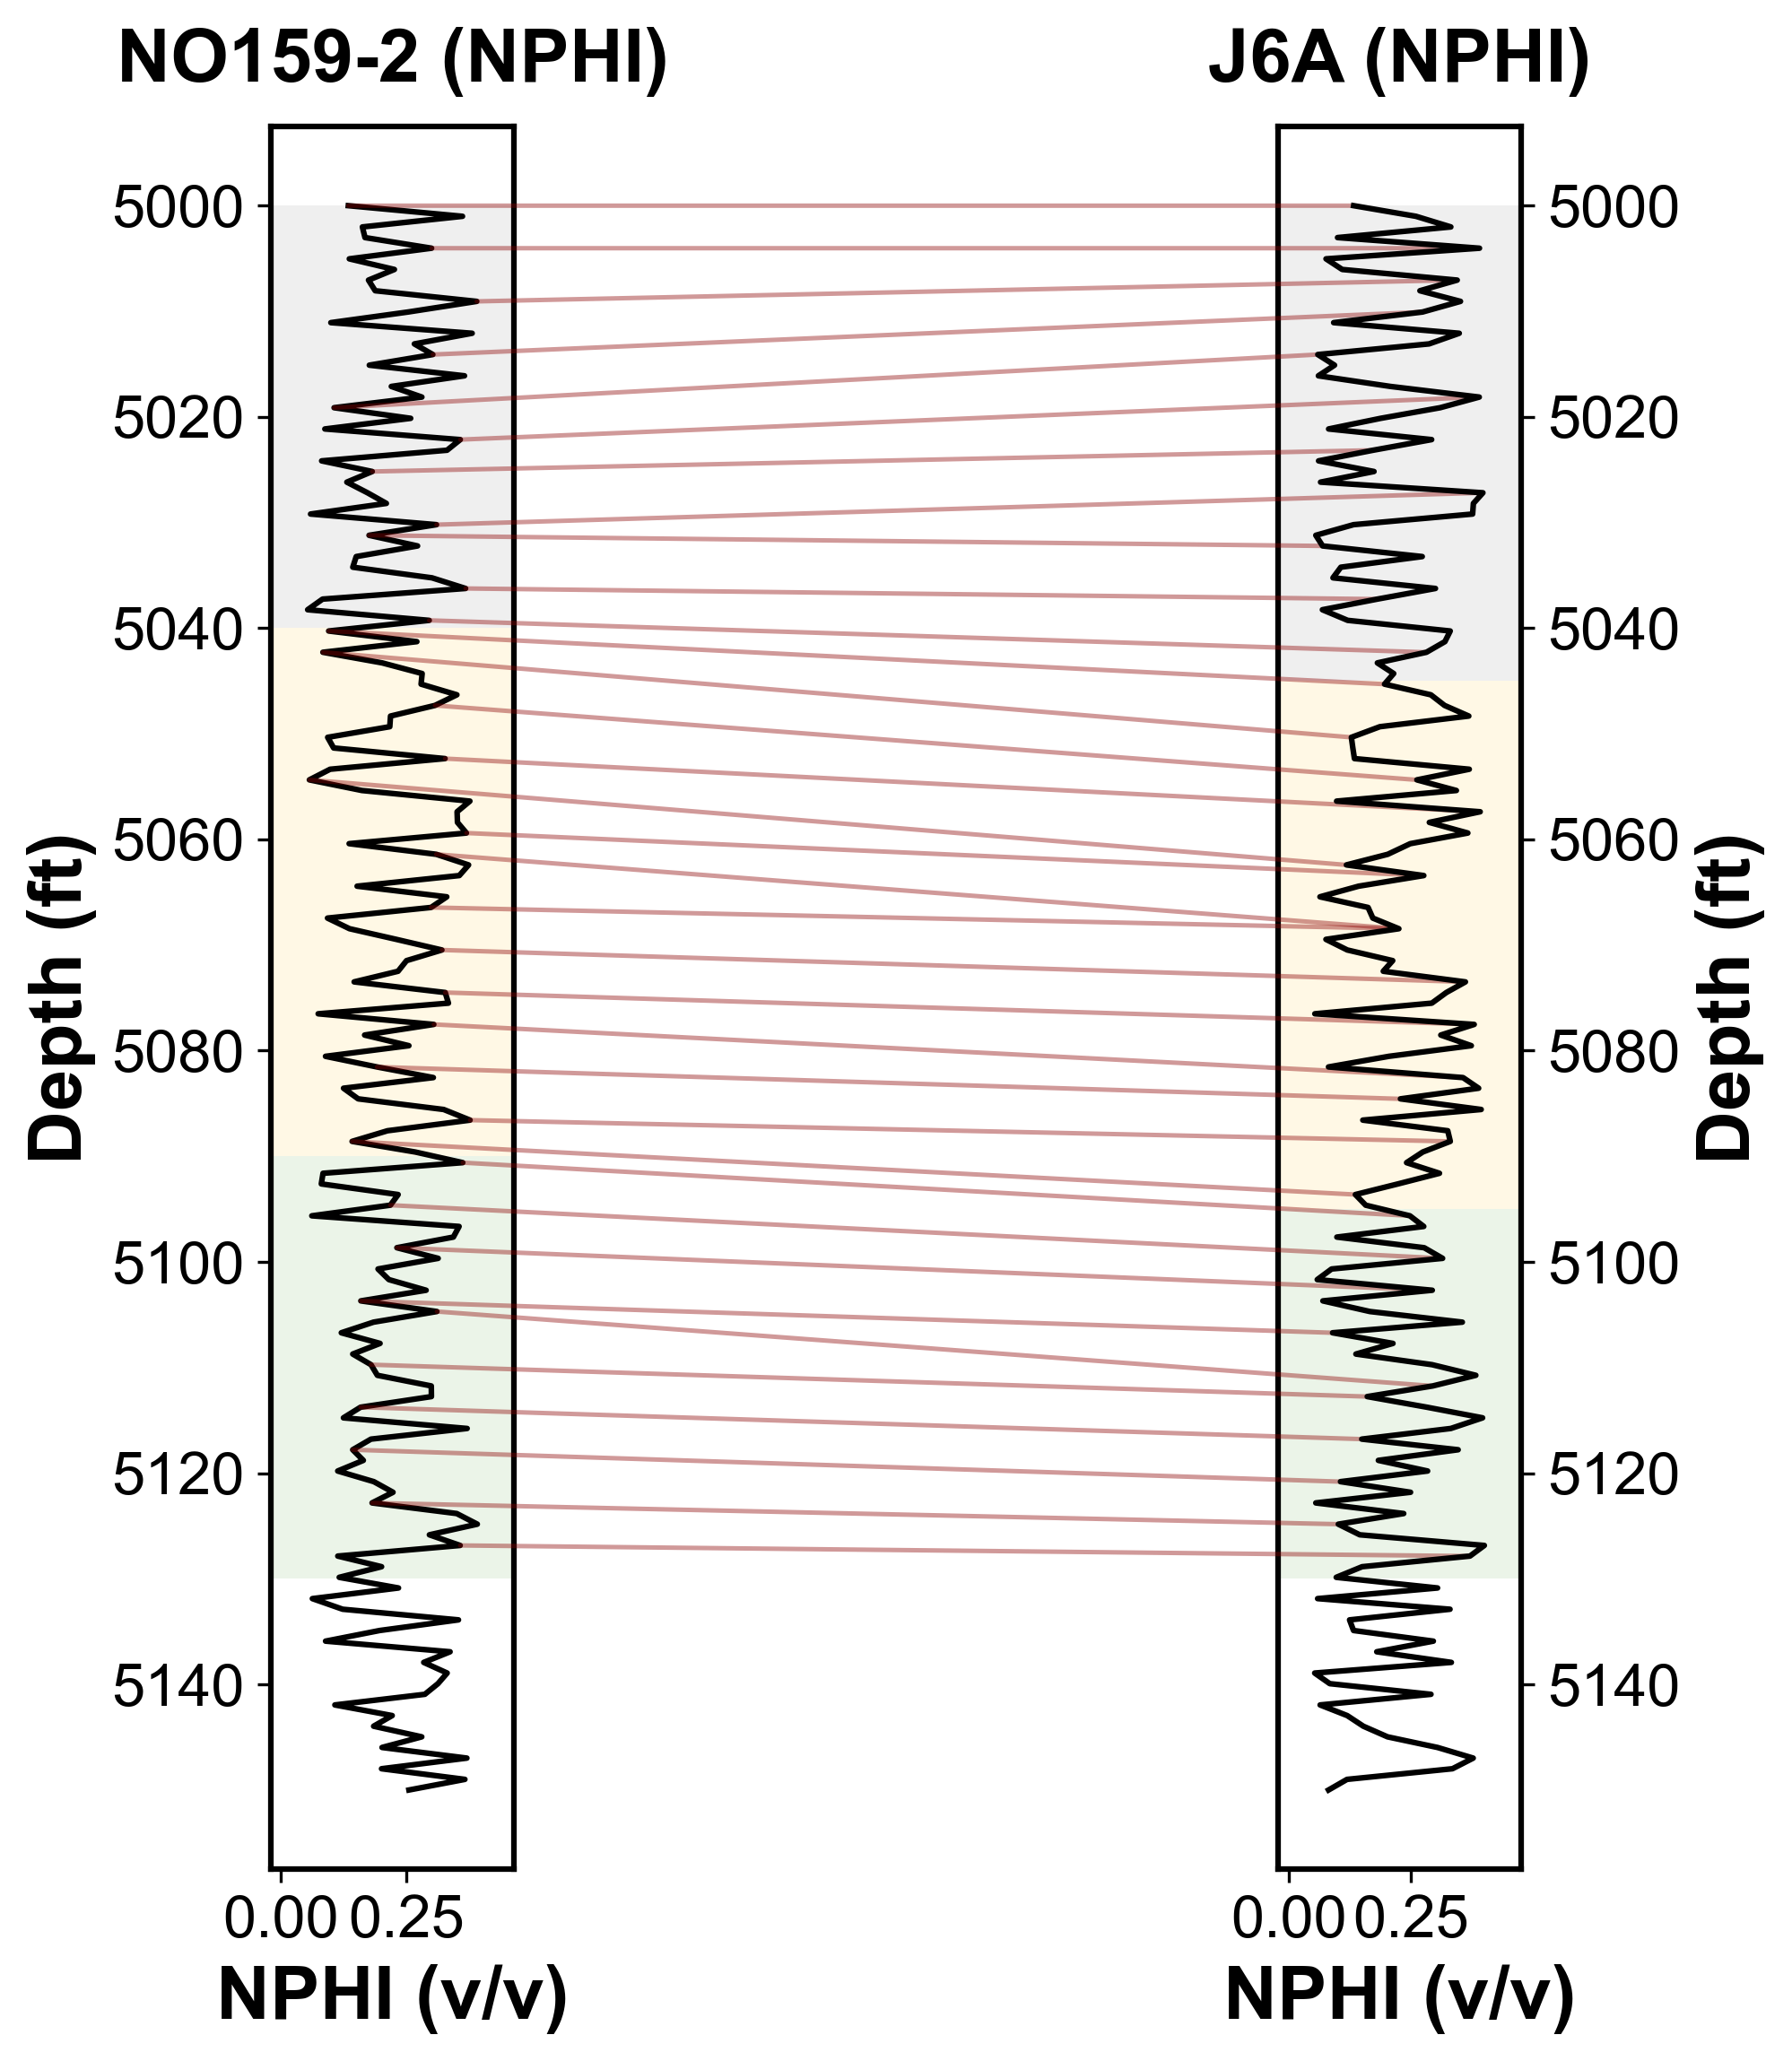

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
from sklearn.preprocessing import StandardScaler

# 1. MATCHING GLOBAL STYLE (Arial + Compact Scaling)
plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 18,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "axes.linewidth": 2,
    "figure.dpi": 300,
    "savefig.dpi": 400
})

def plot_nphi_correlation_matched(df1, df2, zones1, zones2, label1, label2, window_p):
    scaler = StandardScaler()
    
    # 2. MATCHING FIGURE SIZE (7x8)
    fig, axes = plt.subplots(1, 2, figsize=(7, 8))

    # Plot logs and stratigraphic shading
    for i, (df, zones, name) in enumerate([(df1, zones1, label1), (df2, zones2, label2)]):
        ax = axes[i]
        depth = df.iloc[:, 0]
        nphi = df.iloc[:, 2]

        ax.plot(nphi, depth, color='black', lw=1.5, zorder=5)
        ax.invert_yaxis()
        
        # Titles & Labels
        ax.set_title(f"{name} (NPHI)", fontweight='bold', pad=12)
        ax.set_xlabel("NPHI (v/v)")
        ax.set_ylabel("Depth (ft)")

        if i == 1:
            ax.yaxis.set_label_position("right")
            ax.yaxis.tick_right()
        
        # Apply Shading (Fixed warning using facecolor)
        for _, (top, bottom, color) in zones.items():
            ax.axhspan(top, bottom, facecolor=color, alpha=0.5, zorder=2)

        # Spacing between x-ticks padding
        xmin, xmax = ax.get_xlim()
        pad = 0.15 * (xmax - xmin)
        ax.set_xlim(xmin - pad, xmax + pad)

        # Borders (Spines)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
            spine.set_edgecolor('black')

    # 3. FIXED ZONE-BY-ZONE CORRELATION LINES
    # Lowered path step from 120 to 5 since sub-zones in dummy files contain fewer rows
    path_step = 5  
    common_zones = set(zones1.keys()).intersection(set(zones2.keys()))
    
    for z_name in common_zones:
        t1, b1, _ = zones1[z_name]
        t2, b2, _ = zones2[z_name]
        
        mask1 = (df1.iloc[:, 0] >= t1) & (df1.iloc[:, 0] <= b1)
        mask2 = (df2.iloc[:, 0] >= t2) & (df2.iloc[:, 0] <= b2)
        
        sub_df1 = df1[mask1]
        sub_df2 = df2[mask2]
        
        # Lowered minimum length requirement to fit dummy validation thresholds
        if len(sub_df1) > 2 and len(sub_df2) > 2:
            s1_sub = scaler.fit_transform(sub_df1.iloc[:, 2].values.reshape(-1,1)).flatten()
            s2_sub = scaler.fit_transform(sub_df2.iloc[:, 2].values.reshape(-1,1)).flatten()
            
            sub_path = dtw_with_path(s1_sub, s2_sub, window_p)
            
            for idx in range(0, len(sub_path), path_step):
                idx1, idx2 = sub_path[idx]
                y1, x1 = sub_df1.iloc[idx1, 0], sub_df1.iloc[idx1, 2]
                y2, x2 = sub_df2.iloc[idx2, 0], sub_df2.iloc[idx2, 2]
                
                con = ConnectionPatch(xyA=(x1, y1), xyB=(x2, y2), 
                                      coordsA="data", coordsB="data",
                                      axesA=axes[0], axesB=axes[1], 
                                      color="darkred", alpha=0.4, lw=1.2, zorder=4)
                axes[1].add_artist(con)

    plt.tight_layout()
    
    # 4. SAVE
    #if not os.path.exists('L_curve'): os.makedirs('L_curve')
    save_name = f"L_curve/{label1}_{label2}_NPHI_Correlation.jpg"
    #plt.savefig(save_name, bbox_inches='tight', pad_inches=0.02, dpi=300)
    
    print(f"Matched Correlation Plot saved to: {save_name}")
    plt.show

plot_nphi_correlation_matched(df_no159, df_j6a, zones_no159_2_dummy, zones_j6a_dummy, "NO159-2", "J6A", 0.07)